<a href="https://colab.research.google.com/github/Vicianzu/la-baia-di-maldacena/blob/main/test%20livolsi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 39.9 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.5 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 46.0.5 which is incompatible.
Totale eventi trovati: 341
Processing: GW150914

/usr/local/lib/python3.12/dist-packages/scipy/signal/_signaltools.py:283: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  return convolve(in1, _reverse_and_conj(in2, xp), mode, method)


Processing: GW190425-v2
Processing: GW190425_081805-v3
Processing: GW190426_152155-v1
Processing: GW190426_152155-v2
Processing: GW190426_190642-v1
Processing: GW190503_185404-v1
Processing: GW190503_185404-v2
Processing: GW190503_185404-v3
Processing: GW190512_180714-v1
Processing: GW190512_180714-v2
Processing: GW190512_180714-v3
Processing: GW190513_205428-v1
Processing: GW190513_205428-v2
Processing: GW190513_205428-v3
Processing: GW190514_065416-v1
Processing: GW190514_065416-v2
Processing: GW190514_065416-v3
Processing: GW190517_055101-v1
Processing: GW190517_055101-v2
Processing: GW190517_055101-v3
Processing: GW190519_153544-v1
Processing: GW190519_153544-v2
Processing: GW190519_153544-v3
Processing: GW190521-v1
Processing: GW190521-v2
Processing: GW190521-v3
Processing: GW190521_030229-v4
Processing: GW190521_074359-v1
Processing: GW190521_074359-v2
Processing: GW190521_074359-v3
Processing: GW190527_092055-v1
Processing: GW190527_092055-v2
Processing: GW190527_092055-v3
Proce

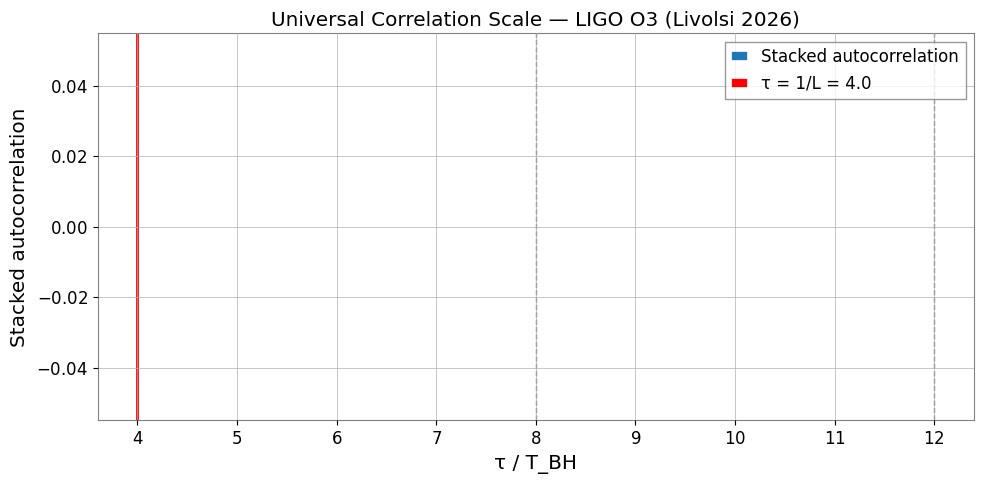

In [1]:
# ============================================================
# Universal Correlation Scale Echoes in LIGO O3
# Edoardo Livolsi — estratto e adattato per Google Colab
# ============================================================

!pip install gwpy gwosc numpy matplotlib scipy

import numpy as np
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from scipy.signal import correlate
from gwosc import datasets

# ── costanti fisiche ────────────────────────────────────────
G          = 6.6743e-11
c          = 299792458
M_sun      = 1.98847e30
sample_rate = 4096
L          = 0.25          # la costante "universale" di Livolsi

# ── lista eventi ────────────────────────────────────────────
events = [e for e in datasets.find_datasets(type="event") if e.startswith("GW")]
print(f"Totale eventi trovati: {len(events)}")

# ── griglia dimensionless tau ────────────────────────────────
tau_grid = np.linspace(0, 10, 4000)
stack    = np.zeros_like(tau_grid)
used     = 0
failed   = 0

# ── loop principale ─────────────────────────────────────────
for ev in events:
    try:
        print(f"Processing: {ev}")
        gps   = datasets.event_gps(ev)
        start = gps - 1
        end   = gps + 6

        # fetch dati grezzi da H1
        data = TimeSeries.fetch_open_data("H1", start, end)
        data = data.whiten()

        # finestra post-merger
        post = data.crop(gps, gps + 5)
        d    = post.value
        d    = (d - np.mean(d)) / np.std(d)

        # autocorrelazione normalizzata
        corr = correlate(d, d, mode="full")
        corr = corr / np.max(np.abs(corr))

        lags = np.arange(-len(d) + 1, len(d)) / sample_rate
        mask = lags > 0
        corr = corr[mask]
        lags = lags[mask]

        # stima frequenza ringdown dagli zero-crossing
        peak = np.argmax(np.abs(d))
        freq = 1 / np.mean(
            np.diff(
                np.where(np.diff(np.sign(d[peak:peak + 200])))[0] + 1
            )
        )

        # stima massa buco nero finale
        M_est = c**3 / (2 * np.pi * G * freq) / M_sun
        Mkg   = M_est * M_sun
        T_BH  = G * Mkg / c**3

        # riscalamento dimensionless
        tau   = lags / T_BH
        interp = np.interp(tau_grid, tau, corr, left=0, right=0)
        stack += interp
        used  += 1

    except Exception as ex:
        failed += 1
        print(f"  → fallito ({ex})")

print(f"\nEventi usati:   {used}")
print(f"Eventi falliti: {failed}")

# ── normalizzazione e smoothing ──────────────────────────────
stack /= used

kernel = np.ones(40) / 40
stack  = np.convolve(stack, kernel, mode="same")

# ── plot ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(tau_grid, stack, label="Stacked autocorrelation", lw=1.5)
plt.axvline(4,  color="red",  lw=2,      label=f"τ = 1/L = {1/L:.1f}")
plt.axvline(8,  color="gray", lw=1, ls="--")
plt.axvline(12, color="gray", lw=1, ls="--")
plt.xlabel("τ / T_BH")
plt.ylabel("Stacked autocorrelation")
plt.title("Universal Correlation Scale — LIGO O3 (Livolsi 2026)")
plt.legend()
plt.tight_layout()
plt.show()